In [250]:
import torch
import numpy as np
from nltk.sentiment.util import split_train_test

np.set_printoptions(precision=3)
a = [1, 2, 3]
b = np.array([4, 5, 6], dtype=np.int32)
t_a = torch.tensor(a)
t_b = torch.from_numpy(b)
print(t_a)
print(t_b)

tensor([1, 2, 3])
tensor([4, 5, 6], dtype=torch.int32)


In [251]:
# создает единичный тензор с заданными измерениями
t_ones = torch.ones(2, 3)
print(t_ones.shape)
print(t_ones)

torch.Size([2, 3])
tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [252]:
# создает тензор со случайными числами в диапазоне [0, 1]
rand_tensor = torch.rand(2, 3)
print(rand_tensor)

tensor([[0.6360, 0.7219, 0.6486],
        [0.4237, 0.1129, 0.8183]])


In [253]:
# меняет тип данных в тензоре
t_a_new = t_a.to(torch.int64)
print(t_a_new.dtype)

torch.int64


In [254]:
t = torch.rand(3, 5)
# транспонирует тензор
t_tr = torch.transpose(t, 0, 1)
print(t.shape, "-->", t_tr.shape)

torch.Size([3, 5]) --> torch.Size([5, 3])


In [255]:
# создает тензор, заполненный нулями
t = torch.zeros(30)
# изменяет размерность тензора
t_reshape = t.reshape(5, 6)
print(t_reshape.shape)

torch.Size([5, 6])


In [256]:
t = torch.zeros(1, 2, 1, 4, 1)
# удаляет заданное измерение
t_sqz = torch.squeeze(t, 2)
print(t.shape, '-->', t_sqz.shape)

torch.Size([1, 2, 1, 4, 1]) --> torch.Size([1, 2, 4, 1])


In [257]:
torch.manual_seed(1)
t1 = 2 * torch.rand(5, 2) - 1
t2 = torch.normal(mean=0, std=1, size=(5, 2))

In [258]:
# выполняет поэлементное произведение
# тензоров при одинаковой размерности
t3 = torch.multiply(t1, t2)
print(t3)

tensor([[ 0.4426, -0.3114],
        [ 0.0660, -0.5970],
        [ 1.1249,  0.0150],
        [ 0.1569,  0.7107],
        [-0.0451, -0.0352]])


In [259]:
# Среднее значение по тензору
# (axis ищет среднее только по одному из измерений)
t4 = torch.mean(t1, axis=0)
print(t4)

tensor([-0.1373,  0.2028])


In [260]:
# Произведение двух тензоров
t5 = torch.matmul(t1, torch.transpose(t2, 0, 1))
print(t5)

tensor([[ 0.1312,  0.3860, -0.6267, -1.0096, -0.2943],
        [ 0.1647, -0.5310,  0.2434,  0.8035,  0.1980],
        [-0.3855, -0.4422,  1.1399,  1.5558,  0.4781],
        [ 0.1822, -0.5771,  0.2585,  0.8676,  0.2132],
        [ 0.0330,  0.1084, -0.1692, -0.2771, -0.0804]])


In [261]:
# Произведение двух тензоров
t6 = torch.matmul(torch.transpose(t1, 0, 1), t2)
print(t6)

tensor([[ 1.7453,  0.3392],
        [-1.6038, -0.2180]])


In [262]:
# L2 нормализация тензора
norm_t1 = torch.linalg.norm(t1, ord=2, dim=1)
print(norm_t1)

tensor([0.6785, 0.5078, 1.1162, 0.5488, 0.1853])


In [263]:
torch.manual_seed(1)
t = torch.rand(6)
print(t)

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293, 0.7999])


In [264]:
# создает из существующего тензора тензор с указанным кол-вом тензоров по указанному измерению
t_splits = torch.chunk(t, 3, dim=0)
[item.numpy() for item in t_splits]

[array([0.758, 0.279], dtype=float32),
 array([0.403, 0.735], dtype=float32),
 array([0.029, 0.8  ], dtype=float32)]

In [265]:
# объединяет два тензора в один
A = torch.ones(3)
B = torch.zeros(2)
C = torch.cat([A, B], axis=0)
print(C)

tensor([1., 1., 1., 0., 0.])


In [266]:
# выполняет стекирование двух тензоров
A = torch.ones(3)
B = torch.zeros(3)
S = torch.stack([A, B], axis=1)
print(S)

tensor([[1., 0.],
        [1., 0.],
        [1., 0.]])


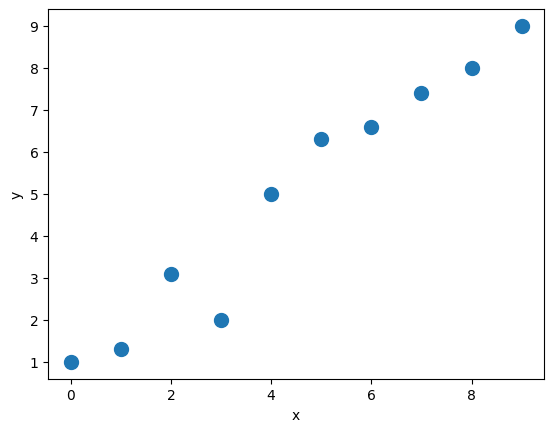

In [267]:
import matplotlib.pyplot as plt
import numpy as np

X_train = np.arange(10, dtype='float32').reshape((10, 1))
y_train = np.array([1., 1.3, 3.1, 2., 5., 6.3, 6.6, 7.4, 8., 9.], dtype='float32')
plt.plot(X_train, y_train, 'o', markersize=10)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [268]:
from torch.utils.data import TensorDataset, DataLoader

X_train_norm = (X_train - np.mean(X_train) / np.std(X_train))
X_train_norm = torch.from_numpy(X_train_norm)
y_train = torch.from_numpy(y_train).float()
train_ds = TensorDataset(X_train_norm, y_train)
train_dl = DataLoader(train_ds, batch_size=1, shuffle=True)

In [269]:
torch.manual_seed(1)
weight = torch.randn(1)
weight.requires_grad_()
bias = torch.zeros(1, requires_grad=True)


def model(xb):
    return xb @ weight + bias


def loss_fn(input, target):
    return (input - target).pow(2).mean()

In [270]:
learning_rate = 0.001
num_epochs = 200
log_epochs = 10
for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch.long())
        loss.backward()
    with torch.no_grad():
        weight -= weight.grad * learning_rate
        bias -= bias.grad * learning_rate
        weight.grad.zero_()
        bias.grad.zero_()
    if epoch % log_epochs == 0:
        print(f'Эпоха {epoch} Потеря {loss.item():.4f}')

Эпоха 0 Потеря 11.6054
Эпоха 10 Потеря 2.0960
Эпоха 20 Потеря 1.5434
Эпоха 30 Потеря 0.0838
Эпоха 40 Потеря 0.1946
Эпоха 50 Потеря 0.0101
Эпоха 60 Потеря 3.2745
Эпоха 70 Потеря 0.1098
Эпоха 80 Потеря 1.3921
Эпоха 90 Потеря 2.1280
Эпоха 100 Потеря 0.0620
Эпоха 110 Потеря 1.1070
Эпоха 120 Потеря 0.0227
Эпоха 130 Потеря 1.1110
Эпоха 140 Потеря 0.0289
Эпоха 150 Потеря 1.1094
Эпоха 160 Потеря 0.0172
Эпоха 170 Потеря 0.0151
Эпоха 180 Потеря 0.0153
Эпоха 190 Потеря 0.0111


In [271]:
print('Окончательные параметры: ', weight.item(), bias.item())

Окончательные параметры:  0.9851818680763245 1.7727298736572266


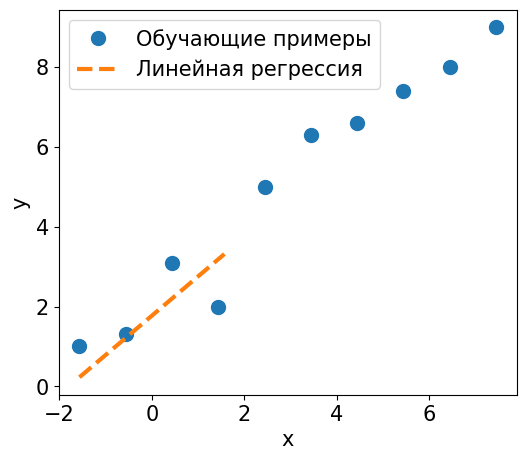

In [272]:
X_test = np.linspace(0, 9, num=100, dtype='float32').reshape(-1, 1)
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm)
y_pred = model(X_test_norm).detach().numpy()
fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm, y_train, 'o', markersize=10)
plt.plot(X_test_norm, y_pred, '--', lw=3)
plt.legend(['Обучающие примеры', 'Линейная регрессия'], fontsize=15)
ax.set_xlabel('x', size=15)
ax.set_ylabel('y', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.show()

In [273]:
import torch.nn as nn

loss_fn = nn.MSELoss(reduction='mean')
input_size = 1
output_size = 1
model = nn.Linear(input_size, output_size)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [274]:
for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)[:, 0]
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    if epoch % log_epochs == 0:
        print(f'Эпохи {epoch} Потери {loss.item():.4f}')

Эпохи 0 Потери 23.8464
Эпохи 10 Потери 2.9730
Эпохи 20 Потери 2.3619
Эпохи 30 Потери 4.8879
Эпохи 40 Потери 0.0140
Эпохи 50 Потери 2.6792
Эпохи 60 Потери 0.4032
Эпохи 70 Потери 1.2157
Эпохи 80 Потери 0.4338
Эпохи 90 Потери 1.6203
Эпохи 100 Потери 0.1553
Эпохи 110 Потери 0.1495
Эпохи 120 Потери 1.1948
Эпохи 130 Потери 0.0704
Эпохи 140 Потери 0.0431
Эпохи 150 Потери 0.0237
Эпохи 160 Потери 0.0113
Эпохи 170 Потери 0.0041
Эпохи 180 Потери 0.1089
Эпохи 190 Потери 0.4755


In [275]:
print('Окончательные параметры: ', model.weight.item(), model.bias.item())


Окончательные параметры:  0.9948357939720154 1.9062458276748657


In [276]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris['data']
y = iris['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=1. / 3, random_state=1)


In [277]:
X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm).float()
y_train = torch.from_numpy(y_train)
train_ds = TensorDataset(X_train_norm, y_train)
torch.manual_seed(1)
batch_size = 2
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [278]:
class Model(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.layer1(x)
        x = nn.Sigmoid()(x)
        x = self.layer2(x)
        return x


input_size = X_train_norm.shape[1]
hidden_size = 16
output_size = 3
model = Model(input_size, hidden_size, output_size)

In [279]:
learning_rate = 0.001
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [280]:
num_epochs = 100
loss_hist = [0] * num_epochs
accuracy_hist = [0] * num_epochs
for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_hist[epoch] += loss.item() * y_batch.size(0)
        is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
        accuracy_hist[epoch] += is_correct.sum()
    loss_hist[epoch] /= len(train_dl.dataset)
    accuracy_hist[epoch] /= len(train_dl.dataset)

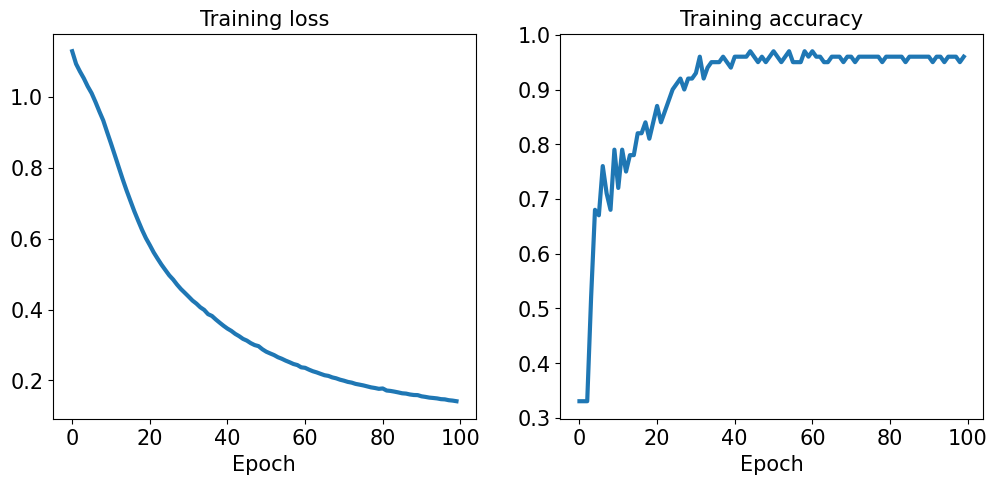

In [281]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(loss_hist, lw=3)
ax.set_title('Training loss', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax = fig.add_subplot(1, 2, 2)
ax.plot(accuracy_hist, lw=3)
ax.set_title('Training accuracy', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.show()

In [282]:
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm).float()
y_test = torch.from_numpy(y_test)
pred_test = model(X_test_norm)
correct = (torch.argmax(pred_test, dim=1) == y_test).float()
accuracy = correct.mean()
print(f'Точность на тестовых данных {accuracy:.4f}')

Точность на тестовых данных 0.9800


In [283]:
path = 'iris_classifier.pt'
torch.save(model, path)

In [287]:
model_new = torch.load(path, weights_only=False)
model_new.eval()

Model(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=3, bias=True)
)

In [292]:
pred_test = model_new(X_test_norm)
correct = (torch.argmax(pred_test, dim=1) == y_test).float()
accuracy = correct.mean()
print(f'Точность на тестовых данных {accuracy:.4f}')

Точность на тестовых данных 0.9800
